# 🫀 Heart Disease Data Analysis — Medical Dataset
**Dataset:** `HeartDiseaseData.csv` — 1,025 patient records (after cleaning: 302 unique)  
**Goal:** Analyze risk factors, identify patterns, and find the strongest predictors of heart disease  
**Tools:** Python · Pandas · NumPy · Matplotlib · Seaborn

> ⚠️ **Medical Disclaimer:** This analysis is for educational and data science purposes only.  
> It does not constitute medical advice. Always consult a qualified healthcare professional.

## 📋 Column Dictionary
| Column | Description |
|---|---|
| `age` | Patient age in years |
| `sex` | 1 = Male, 0 = Female |
| `cp` | Chest pain type: 0=Typical Angina, 1=Atypical Angina, 2=Non-anginal, 3=Asymptomatic |
| `trestbps` | Resting blood pressure (mm Hg) |
| `chol` | Serum cholesterol (mg/dl) |
| `fbs` | Fasting blood sugar > 120 mg/dl (1=True, 0=False) |
| `restecg` | Resting ECG results (0, 1, 2) |
| `thalach` | Maximum heart rate achieved |
| `exang` | Exercise-induced angina (1=Yes, 0=No) |
| `oldpeak` | ST depression induced by exercise |
| `slope` | Slope of peak exercise ST segment |
| `ca` | Number of major vessels colored by fluoroscopy (0–3) |
| `thal` | Thalassemia: 0=Normal, 1=Fixed Defect, 2=Reversible Defect |
| `target` | **1 = Heart Disease, 0 = No Heart Disease** |


## 1. Imports

In [38]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Dataset

In [39]:
data = pd.read_csv('HeartDiseaseData.csv')
print(f"Dataset loaded: {len(data):,} rows × {len(data.columns)} columns")

Dataset loaded: 1,025 rows × 14 columns


## 3. First Look at the Data

In [40]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [41]:
data.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1
1024,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0


## 4. Data Structure & Info

In [42]:
print("Shape:", data.shape)

Shape: (1025, 14)


In [43]:
data.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

In [44]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [45]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1025.0,54.434146,9.072290,29.0,48.0,56.0,61.0,77.0
sex,1025.0,0.695610,0.460373,0.0,0.0,1.0,1.0,1.0
cp,1025.0,0.942439,1.029641,0.0,0.0,1.0,2.0,3.0
trestbps,1025.0,131.611707,17.516718,94.0,120.0,130.0,140.0,200.0
chol,1025.0,246.000000,51.592510,126.0,211.0,240.0,275.0,564.0
fbs,1025.0,0.149268,0.356527,0.0,0.0,0.0,0.0,1.0
restecg,1025.0,0.529756,0.527878,0.0,0.0,1.0,1.0,2.0
thalach,1025.0,149.114146,23.005724,71.0,132.0,152.0,166.0,202.0
exang,1025.0,0.336585,0.472772,0.0,0.0,0.0,1.0,1.0
oldpeak,1025.0,1.071512,1.175053,0.0,0.0,0.8,1.8,6.2


## 5. Data Cleaning

In [46]:
# Check missing values
print("Missing values:")
print(data.isnull().sum())
print(f"\nTotal missing: {data.isnull().sum().sum()}")

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Total missing: 0


In [47]:
# Check duplicates — important finding!
print(f"Duplicate rows: {data.duplicated().sum()}")
print(f"That's {data.duplicated().sum()/len(data)*100:.1f}% of the dataset!")

Duplicate rows: 723
That's 70.5% of the dataset!


In [48]:
# Remove duplicates — keep first occurrence
data = data.drop_duplicates()
print(f"Records after removing duplicates: {len(data)}")

Records after removing duplicates: 302


In [49]:
# Add human-readable labels for better analysis
data['target_label'] = data['target'].map({1: 'Heart Disease', 0: 'No Heart Disease'})
data['sex_label']    = data['sex'].map({1: 'Male', 0: 'Female'})
data['cp_label']     = data['cp'].map({
    0: 'Typical Angina',
    1: 'Atypical Angina',
    2: 'Non-anginal Pain',
    3: 'Asymptomatic'
})
data['exang_label']  = data['exang'].map({1: 'Yes', 0: 'No'})

print("Labels added successfully")
data.head()

Labels added successfully


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,target_label,sex_label,cp_label,exang_label
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0,No Heart Disease,Male,Typical Angina,No
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0,No Heart Disease,Male,Typical Angina,Yes
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0,No Heart Disease,Male,Typical Angina,Yes
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0,No Heart Disease,Male,Typical Angina,No
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0,No Heart Disease,Female,Typical Angina,No


---
## 📋 Analytical Questions
---

### Q1 — How Many Patients Have Heart Disease vs No Heart Disease?

In [50]:
target_counts = data['target_label'].value_counts()
print("Patient Distribution:")
print(target_counts)
print()
print(f"Heart Disease    : {target_counts['Heart Disease']:,} patients ({target_counts['Heart Disease']/len(data)*100:.1f}%)")
print(f"No Heart Disease : {target_counts['No Heart Disease']:,} patients ({target_counts['No Heart Disease']/len(data)*100:.1f}%)")

Patient Distribution:
target_label
Heart Disease       164
No Heart Disease    138
Name: count, dtype: int64

Heart Disease    : 164 patients (54.3%)
No Heart Disease : 138 patients (45.7%)


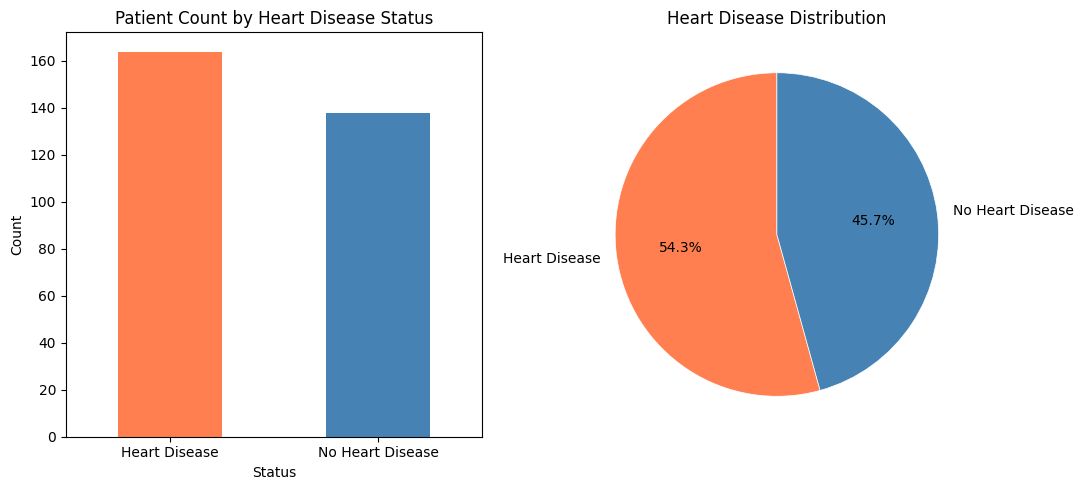

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

target_counts.plot(kind='bar', ax=axes[0], color=['coral', 'steelblue'])
axes[0].set_title("Patient Count by Heart Disease Status")
axes[0].set_xlabel("Status")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=0)

axes[1].pie(target_counts,
            labels=target_counts.index,
            autopct='%1.1f%%',
            colors=['coral', 'steelblue'],
            startangle=90,
            wedgeprops=dict(linewidth=0.5, edgecolor='white'))
axes[1].set_title("Heart Disease Distribution")

plt.tight_layout()
plt.show()

### Q2 — Average Age of Patients With vs Without Heart Disease

In [52]:
avg_age = data.groupby('target_label')['age'].agg(['mean', 'median', 'std']).round(2)
print("Age Statistics by Heart Disease Status:")
print(avg_age)

Age Statistics by Heart Disease Status:
                   mean  median   std
target_label                         
Heart Disease     52.59    52.0  9.51
No Heart Disease  56.60    58.0  7.96


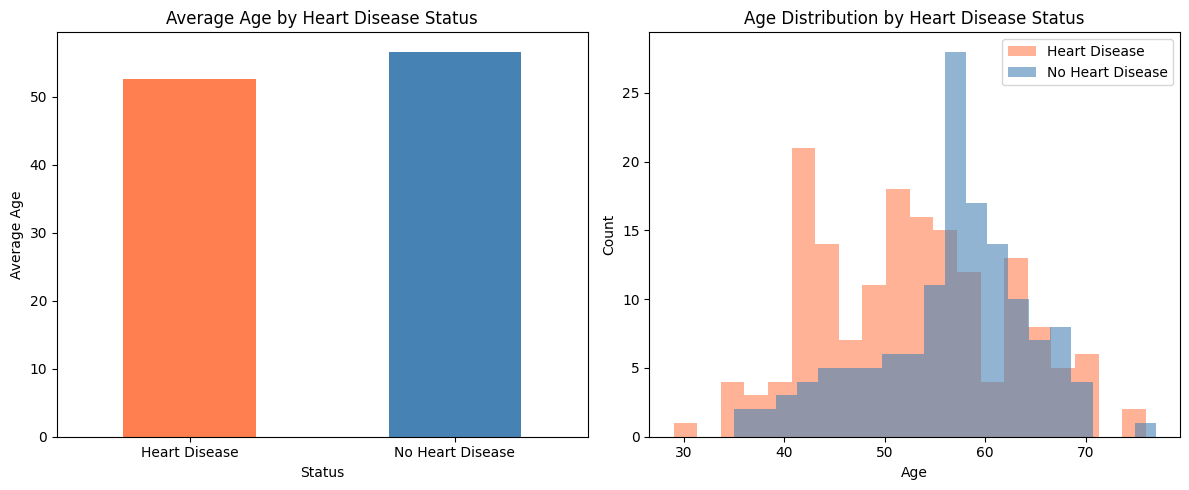

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar: avg age
data.groupby('target_label')['age'].mean().plot(
    kind='bar', ax=axes[0], color=['coral', 'steelblue'])
axes[0].set_title("Average Age by Heart Disease Status")
axes[0].set_xlabel("Status")
axes[0].set_ylabel("Average Age")
axes[0].tick_params(axis='x', rotation=0)

# Histogram: age distribution per group
for label, color in zip(['Heart Disease', 'No Heart Disease'], ['coral', 'steelblue']):
    subset = data[data['target_label'] == label]['age']
    axes[1].hist(subset, bins=20, alpha=0.6, label=label, color=color)
axes[1].set_title("Age Distribution by Heart Disease Status")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.show()

### Q3 — Are Men More Likely to Have Heart Disease Than Women?

In [54]:
# Cross-tabulation: Sex vs Heart Disease
gender_disease = pd.crosstab(data['sex_label'], data['target_label'])
print("Gender vs Heart Disease:")
print(gender_disease)
print()

# As percentage within each gender
gender_pct = pd.crosstab(data['sex_label'], data['target_label'], normalize='index') * 100
print("\nAs percentage within each gender:")
print(gender_pct.round(1))

Gender vs Heart Disease:
target_label  Heart Disease  No Heart Disease
sex_label                                    
Female                   72                24
Male                     92               114


As percentage within each gender:
target_label  Heart Disease  No Heart Disease
sex_label                                    
Female                 75.0              25.0
Male                   44.7              55.3


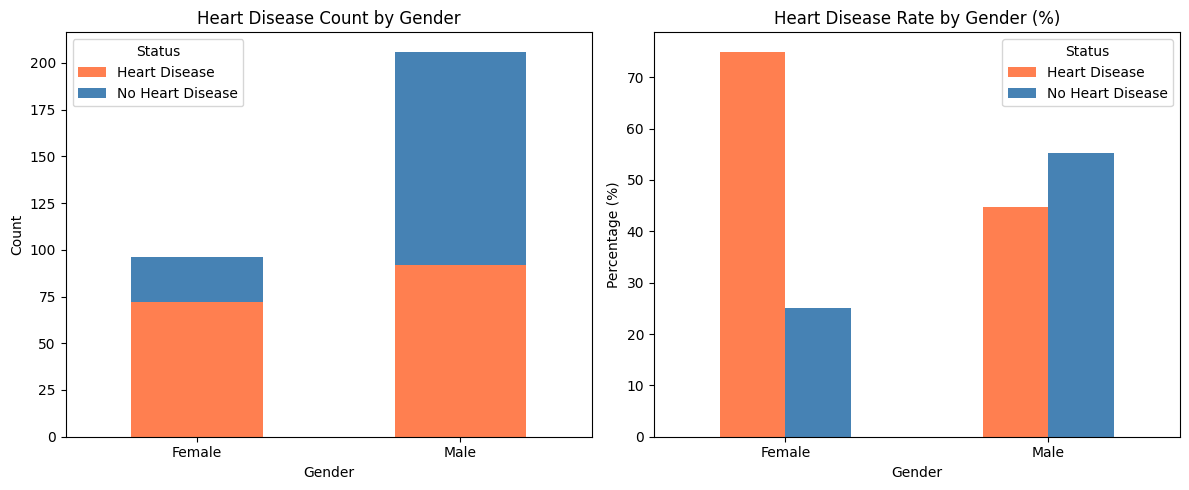

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Stacked bar
gender_disease.plot(kind='bar', ax=axes[0], color=['coral','steelblue'], stacked=True)
axes[0].set_title("Heart Disease Count by Gender")
axes[0].set_xlabel("Gender")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Status')

# Percentage bar
gender_pct.plot(kind='bar', ax=axes[1], color=['coral','steelblue'])
axes[1].set_title("Heart Disease Rate by Gender (%)")
axes[1].set_xlabel("Gender")
axes[1].set_ylabel("Percentage (%)")
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Status')

plt.tight_layout()
plt.show()

### Q4 — Average Cholesterol by Heart Disease Status

In [56]:
chol_stats = data.groupby('target_label')['chol'].agg(['mean','median','std']).round(2)
print("Cholesterol Statistics:")
print(chol_stats)

Cholesterol Statistics:
                    mean  median    std
target_label                           
Heart Disease     242.64   234.5  53.46
No Heart Disease  251.09   249.0  49.45


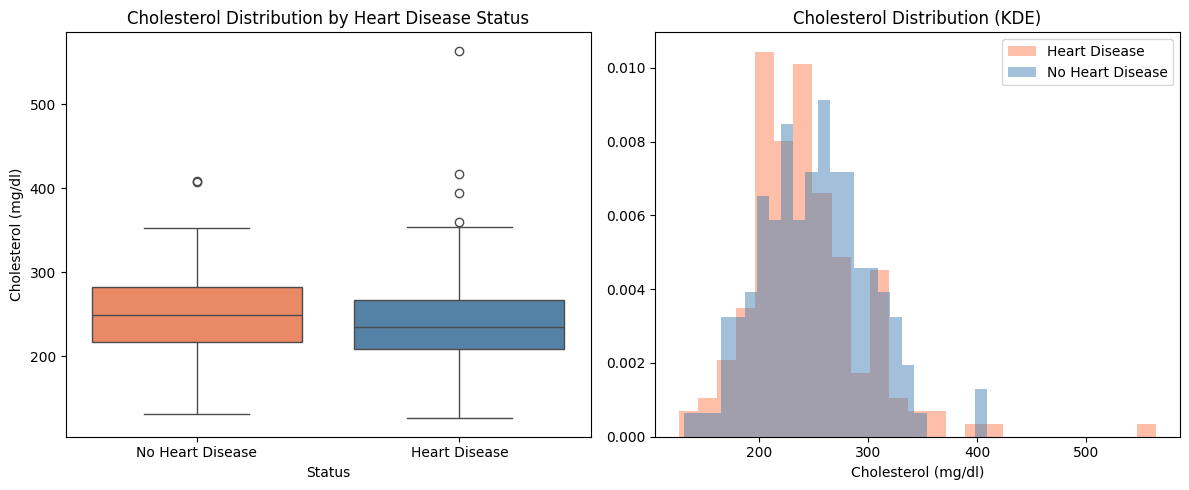

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot
sns.boxplot(x='target_label', y='chol', data=data,
            palette=['coral', 'steelblue'], ax=axes[0])
axes[0].set_title("Cholesterol Distribution by Heart Disease Status")
axes[0].set_xlabel("Status")
axes[0].set_ylabel("Cholesterol (mg/dl)")

# KDE
for label, color in zip(['Heart Disease', 'No Heart Disease'], ['coral', 'steelblue']):
    subset = data[data['target_label'] == label]['chol']
    axes[1].hist(subset, bins=25, alpha=0.5, label=label, color=color, density=True)
axes[1].set_title("Cholesterol Distribution (KDE)")
axes[1].set_xlabel("Cholesterol (mg/dl)")
axes[1].legend()

plt.tight_layout()
plt.show()

### Q5 — Relationship Between Age and Maximum Heart Rate (thalach)

> 💡 **Medical context:**  
> Maximum heart rate (thalach) naturally decreases with age.  
> Formula: Max HR ≈ 220 − Age  
> Patients with heart disease often achieve lower max heart rates during exercise.


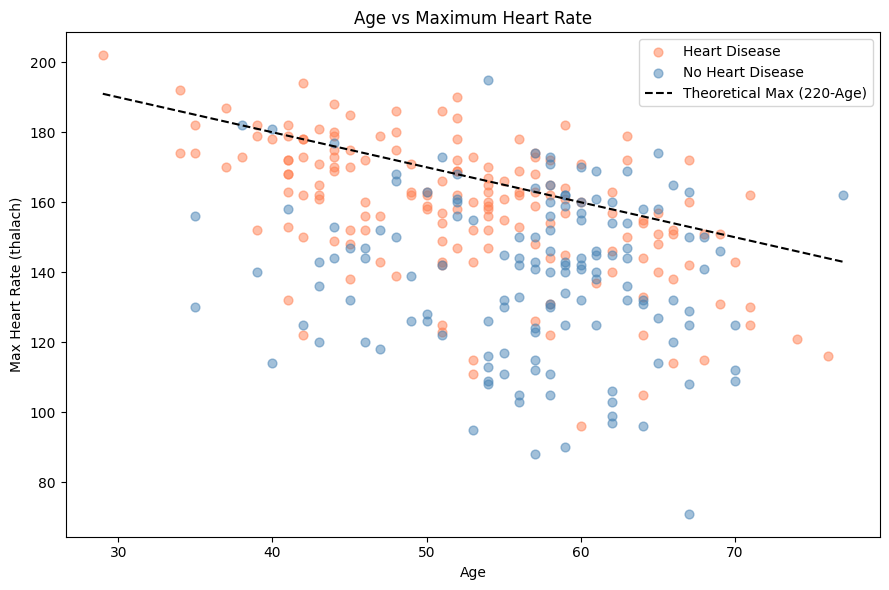

In [58]:
# Scatter: Age vs Max Heart Rate colored by disease status
plt.figure(figsize=(9, 6))
for label, color in zip(['Heart Disease', 'No Heart Disease'], ['coral', 'steelblue']):
    subset = data[data['target_label'] == label]
    plt.scatter(subset['age'], subset['thalach'],
                label=label, color=color, alpha=0.5, s=40)

# Add theoretical max HR line (220 - age)
ages = np.arange(data['age'].min(), data['age'].max()+1)
plt.plot(ages, 220 - ages, 'k--', label='Theoretical Max (220-Age)', linewidth=1.5)

plt.title("Age vs Maximum Heart Rate")
plt.xlabel("Age")
plt.ylabel("Max Heart Rate (thalach)")
plt.legend()
plt.tight_layout()
plt.show()

In [59]:
# Average thalach per age group
data['age_group'] = pd.cut(data['age'], bins=[28,40,50,60,70,80],
                            labels=['29-40','41-50','51-60','61-70','71-80'])

thalach_age = data.groupby(['age_group','target_label'], observed=True)['thalach'].mean().unstack().round(1)
print("Avg Max Heart Rate by Age Group and Disease Status:")
print(thalach_age)

Avg Max Heart Rate by Age Group and Disease Status:
target_label  Heart Disease  No Heart Disease
age_group                                    
29-40                 178.8             150.5
41-50                 165.5             142.7
51-60                 156.7             139.1
61-70                 145.8             135.0
71-80                 130.8             162.0


### Q6 — Which Chest Pain Type is Most Associated with Heart Disease?

In [60]:
# Cross-tabulation: Chest Pain Type vs Heart Disease
cp_disease = pd.crosstab(data['cp_label'], data['target_label'])
print("Chest Pain Type vs Heart Disease:")
print(cp_disease)
print()

# Percentage within each chest pain type
cp_pct = pd.crosstab(data['cp_label'], data['target_label'], normalize='index') * 100
print("\nHeart Disease Rate by Chest Pain Type (%):")
print(cp_pct.round(1))

Chest Pain Type vs Heart Disease:
target_label      Heart Disease  No Heart Disease
cp_label                                         
Asymptomatic                 16                 7
Atypical Angina              41                 9
Non-anginal Pain             68                18
Typical Angina               39               104


Heart Disease Rate by Chest Pain Type (%):
target_label      Heart Disease  No Heart Disease
cp_label                                         
Asymptomatic               69.6              30.4
Atypical Angina            82.0              18.0
Non-anginal Pain           79.1              20.9
Typical Angina             27.3              72.7


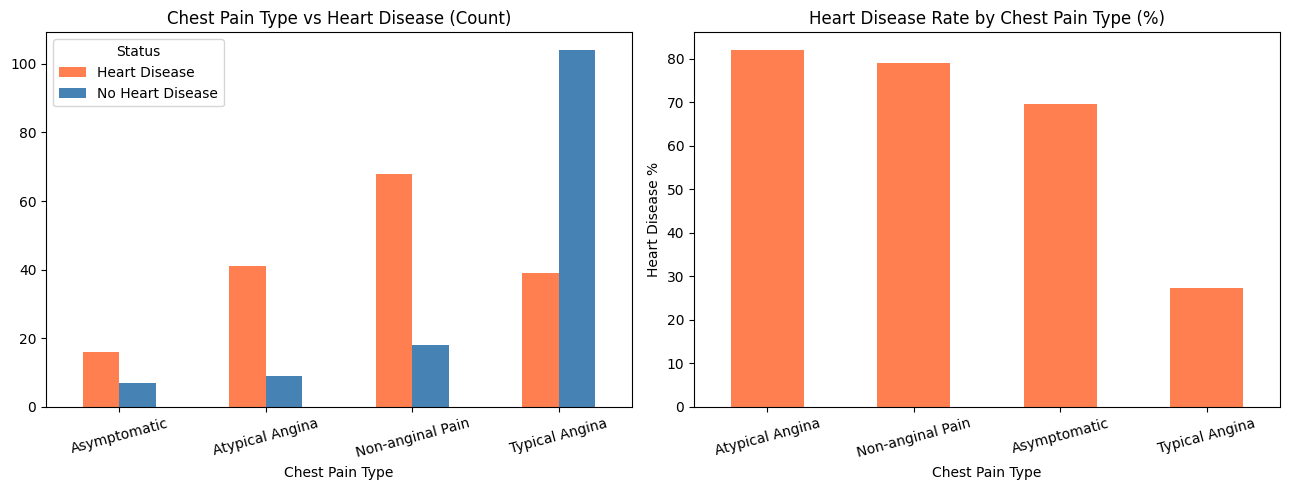

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cp_disease.plot(kind='bar', ax=axes[0], color=['coral','steelblue'])
axes[0].set_title("Chest Pain Type vs Heart Disease (Count)")
axes[0].set_xlabel("Chest Pain Type")
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(title='Status')

cp_pct['Heart Disease'].sort_values(ascending=False).plot(
    kind='bar', ax=axes[1], color='coral')
axes[1].set_title("Heart Disease Rate by Chest Pain Type (%)")
axes[1].set_xlabel("Chest Pain Type")
axes[1].set_ylabel("Heart Disease %")
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

### Q7 — Does High Blood Pressure (trestbps) Relate to Heart Disease?

In [62]:
bp_stats = data.groupby('target_label')['trestbps'].agg(['mean','median','std']).round(2)
print("Blood Pressure Statistics by Heart Disease Status:")
print(bp_stats)

Blood Pressure Statistics by Heart Disease Status:
                    mean  median    std
target_label                           
Heart Disease     129.25   130.0  16.20
No Heart Disease  134.40   130.0  18.73


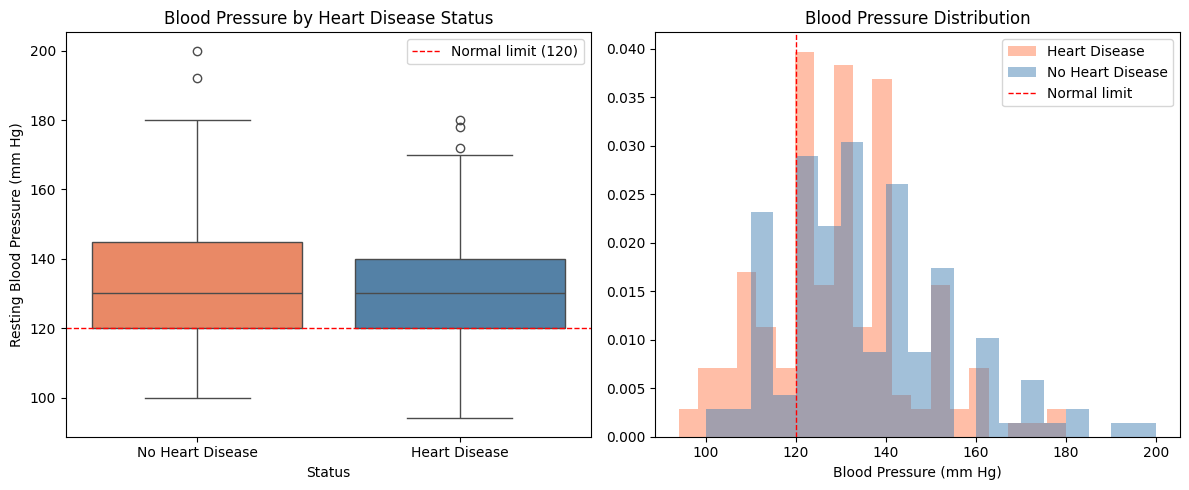

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x='target_label', y='trestbps', data=data,
            palette=['coral','steelblue'], ax=axes[0])
axes[0].set_title("Blood Pressure by Heart Disease Status")
axes[0].set_xlabel("Status")
axes[0].set_ylabel("Resting Blood Pressure (mm Hg)")
axes[0].axhline(120, color='red', linestyle='--', linewidth=1, label='Normal limit (120)')
axes[0].legend()

# Histogram
for label, color in zip(['Heart Disease','No Heart Disease'],['coral','steelblue']):
    subset = data[data['target_label']==label]['trestbps']
    axes[1].hist(subset, bins=20, alpha=0.5, label=label, color=color, density=True)
axes[1].axvline(120, color='red', linestyle='--', linewidth=1, label='Normal limit')
axes[1].set_title("Blood Pressure Distribution")
axes[1].set_xlabel("Blood Pressure (mm Hg)")
axes[1].legend()

plt.tight_layout()
plt.show()

### Q8 — Strongest Variables Correlated with Heart Disease

> 💡 **This is the most important analytical question:**  
> Understanding which features have the highest correlation with the target  
> is the foundation of feature selection in Machine Learning.  
> Positive correlation → more likely to have heart disease  
> Negative correlation → less likely to have heart disease


In [64]:
# Correlation of all features with target
corr_with_target = data.select_dtypes(include='number').corr()['target'].drop('target').sort_values()
print("Correlation with Heart Disease (target):")
print(corr_with_target.round(3))

Correlation with Heart Disease (target):
exang      -0.436
oldpeak    -0.429
ca         -0.409
thal       -0.343
sex        -0.284
age        -0.221
trestbps   -0.146
chol       -0.081
fbs        -0.027
restecg     0.135
slope       0.344
thalach     0.420
cp          0.432
Name: target, dtype: float64


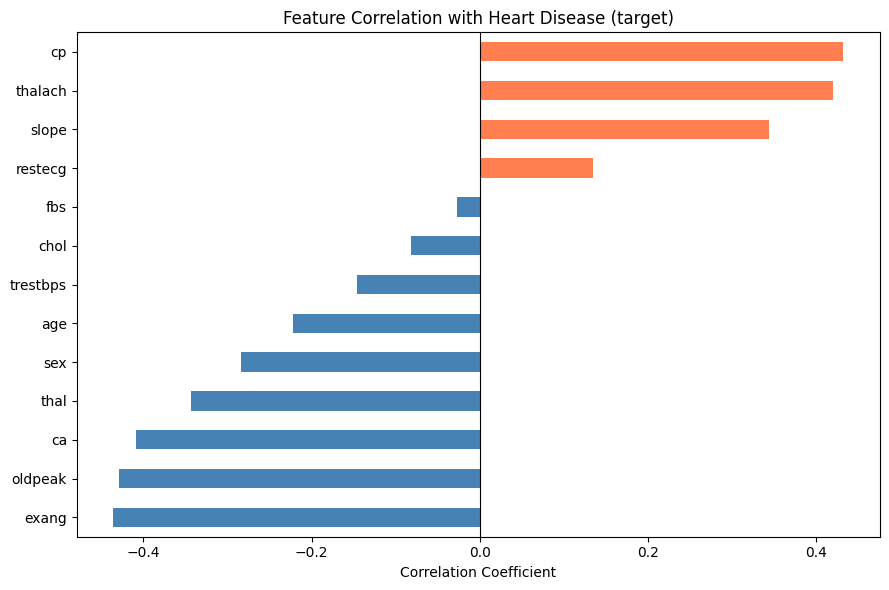

In [65]:
# Bar chart of correlations
plt.figure(figsize=(9, 6))
colors = ['coral' if x > 0 else 'steelblue' for x in corr_with_target]
corr_with_target.plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title("Feature Correlation with Heart Disease (target)")
plt.xlabel("Correlation Coefficient")
plt.tight_layout()
plt.show()

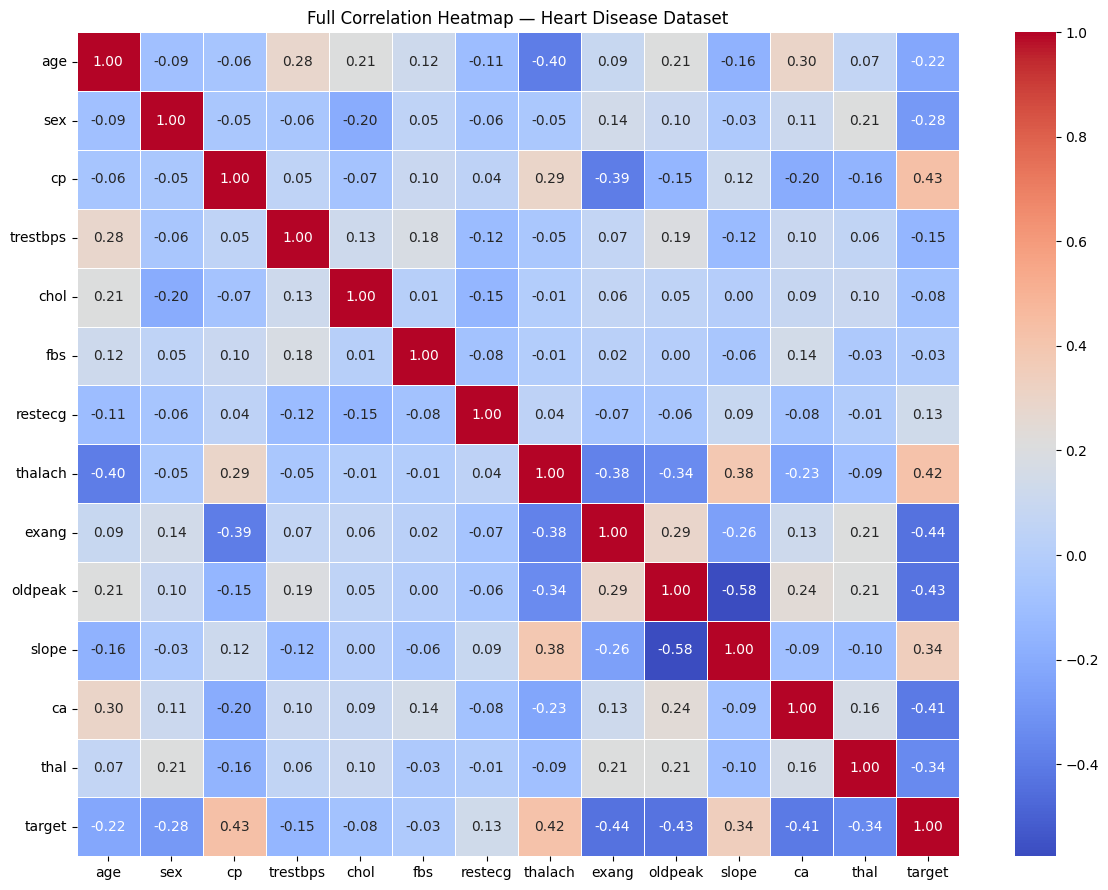

In [66]:
# Full correlation heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(data.select_dtypes(include='number').corr(),
            annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.4, square=False)
plt.title("Full Correlation Heatmap — Heart Disease Dataset")
plt.tight_layout()
plt.show()

### Q9 — Is Exercise-Induced Angina (exang) More Common in Heart Disease Patients?

In [67]:
exang_disease = pd.crosstab(data['exang_label'], data['target_label'])
print("Exercise-Induced Angina vs Heart Disease:")
print(exang_disease)
print()

exang_pct = pd.crosstab(data['exang_label'], data['target_label'], normalize='index') * 100
print("\nHeart Disease Rate by Exang (%):")
print(exang_pct.round(1))

Exercise-Induced Angina vs Heart Disease:
target_label  Heart Disease  No Heart Disease
exang_label                                  
No                      141                62
Yes                      23                76


Heart Disease Rate by Exang (%):
target_label  Heart Disease  No Heart Disease
exang_label                                  
No                     69.5              30.5
Yes                    23.2              76.8


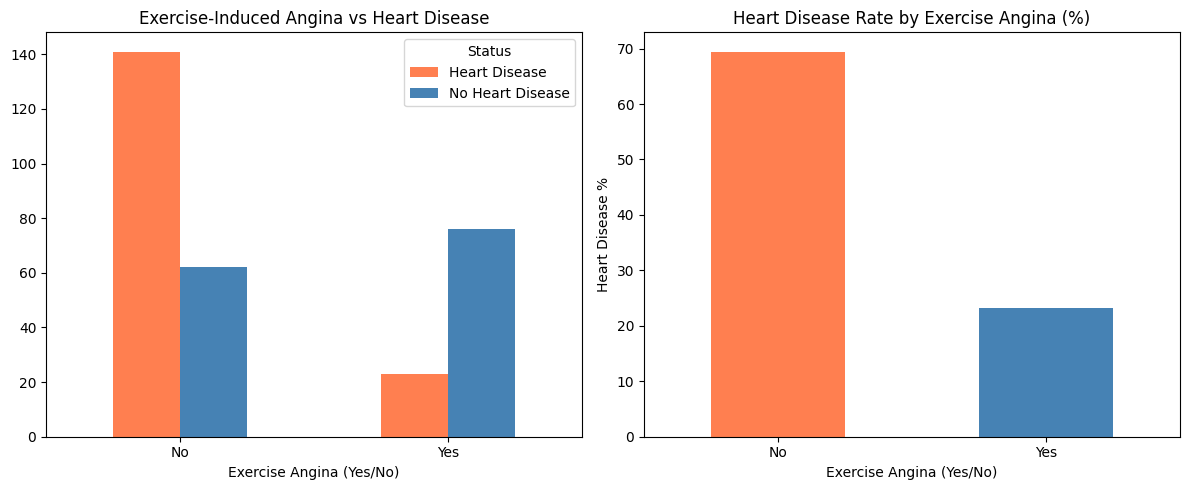

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

exang_disease.plot(kind='bar', ax=axes[0], color=['coral','steelblue'])
axes[0].set_title("Exercise-Induced Angina vs Heart Disease")
axes[0].set_xlabel("Exercise Angina (Yes/No)")
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Status')

exang_pct['Heart Disease'].plot(kind='bar', ax=axes[1], color=['coral','steelblue'])
axes[1].set_title("Heart Disease Rate by Exercise Angina (%)")
axes[1].set_xlabel("Exercise Angina (Yes/No)")
axes[1].set_ylabel("Heart Disease %")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### Q10 — What Are the Characteristics of the Highest-Risk Patients?

> **Defining high-risk patients:**  
> Patients with Heart Disease AND multiple high-risk factors:  
> - Age > 55  
> - trestbps > 140 (high blood pressure)  
> - chol > 240 (high cholesterol)  
> - exang = 1 (exercise-induced angina)  
> - oldpeak > 2 (significant ST depression)


In [69]:
# Define high-risk patients
high_risk = data[
    (data['target'] == 1) &
    (data['age'] > 55) &
    (data['trestbps'] > 140) &
    (data['chol'] > 240) &
    (data['exang'] == 1) &
    (data['oldpeak'] > 2)
]

print(f"High-Risk Patients: {len(high_risk)}")
high_risk[['age','sex_label','cp_label','trestbps','chol','thalach','oldpeak','exang_label']].head(15)

High-Risk Patients: 0


,age,sex_label,cp_label,trestbps,chol,thalach,oldpeak,exang_label


In [70]:
# Statistical profile of high-risk patients vs all heart disease patients
hd_patients = data[data['target'] == 1]
numeric_cols = ['age','trestbps','chol','thalach','oldpeak']

comparison = pd.DataFrame({
    'High_Risk': high_risk[numeric_cols].mean().round(2),
    'All_HeartDisease': hd_patients[numeric_cols].mean().round(2),
    'All_Patients': data[numeric_cols].mean().round(2)
})
print("Profile Comparison:")
comparison

Profile Comparison:


,High_Risk,All_HeartDisease,All_Patients
age,NaN,52.59,54.42
trestbps,NaN,129.25,131.60
chol,NaN,242.64,246.50
thalach,NaN,158.38,149.57
oldpeak,NaN,0.59,1.04


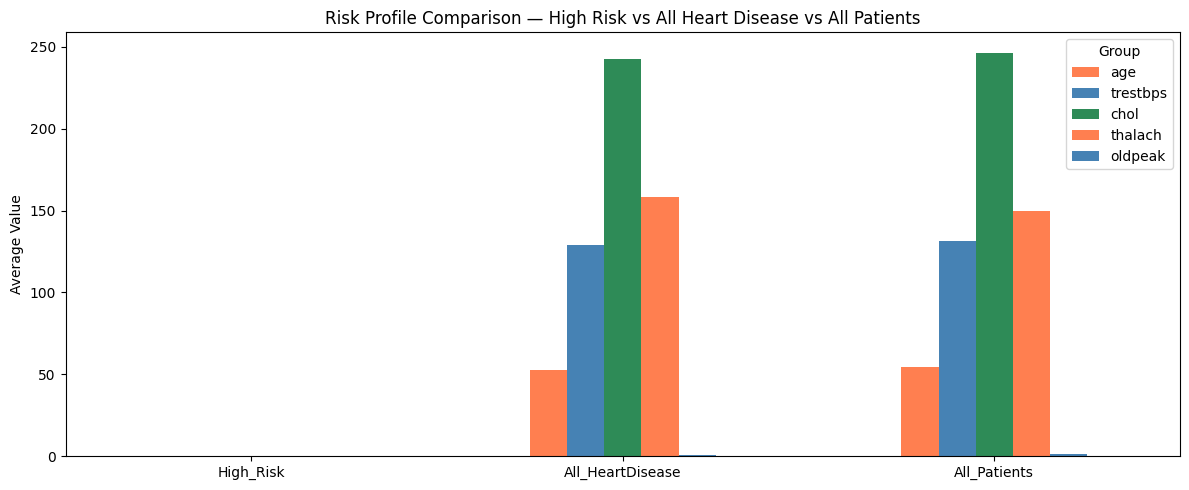

In [71]:
# Radar-style bar comparison
comparison.T.plot(kind='bar', figsize=(12, 5), color=['coral','steelblue','seagreen'])
plt.title("Risk Profile Comparison — High Risk vs All Heart Disease vs All Patients")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.legend(title='Group')
plt.tight_layout()
plt.show()

## 7. Additional Visualizations

### 7.1 Pairplot of Key Variables

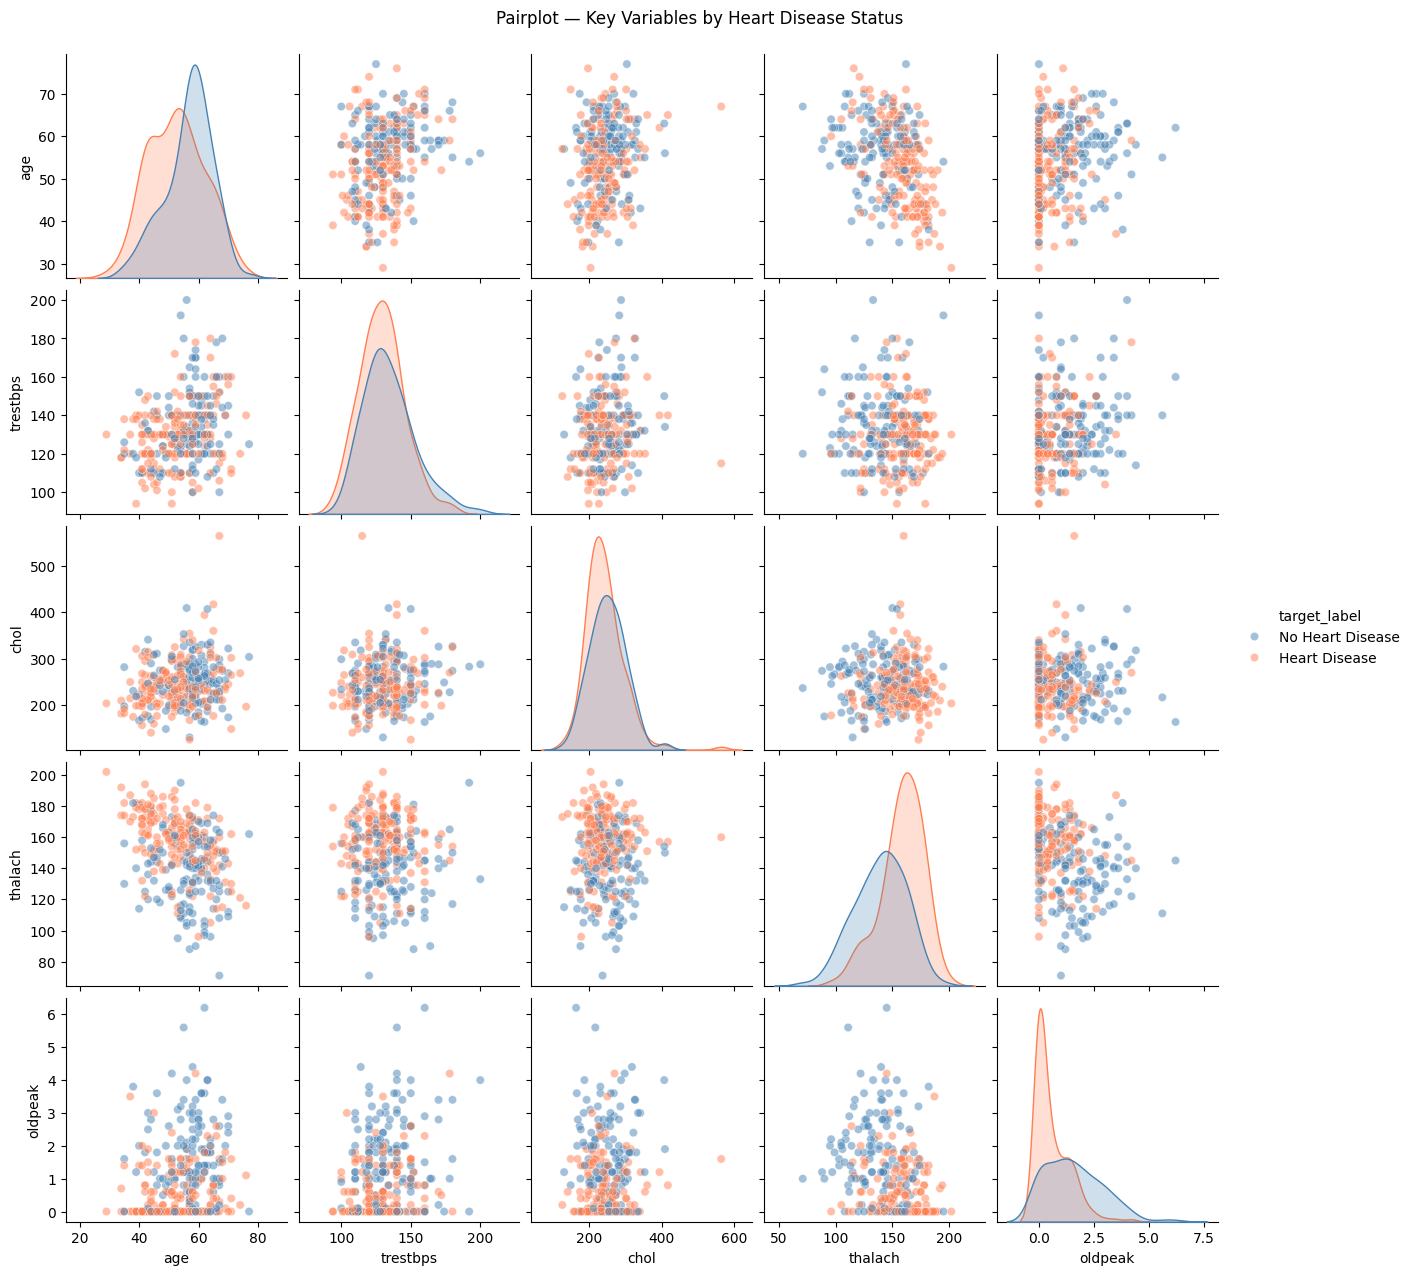

In [72]:
key_vars = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'target_label']
sns.pairplot(data[key_vars], hue='target_label',
             palette={'Heart Disease': 'coral', 'No Heart Disease': 'steelblue'},
             plot_kws={'alpha': 0.5})
plt.suptitle("Pairplot — Key Variables by Heart Disease Status", y=1.02)
plt.show()

### 7.2 Dashboard Summary

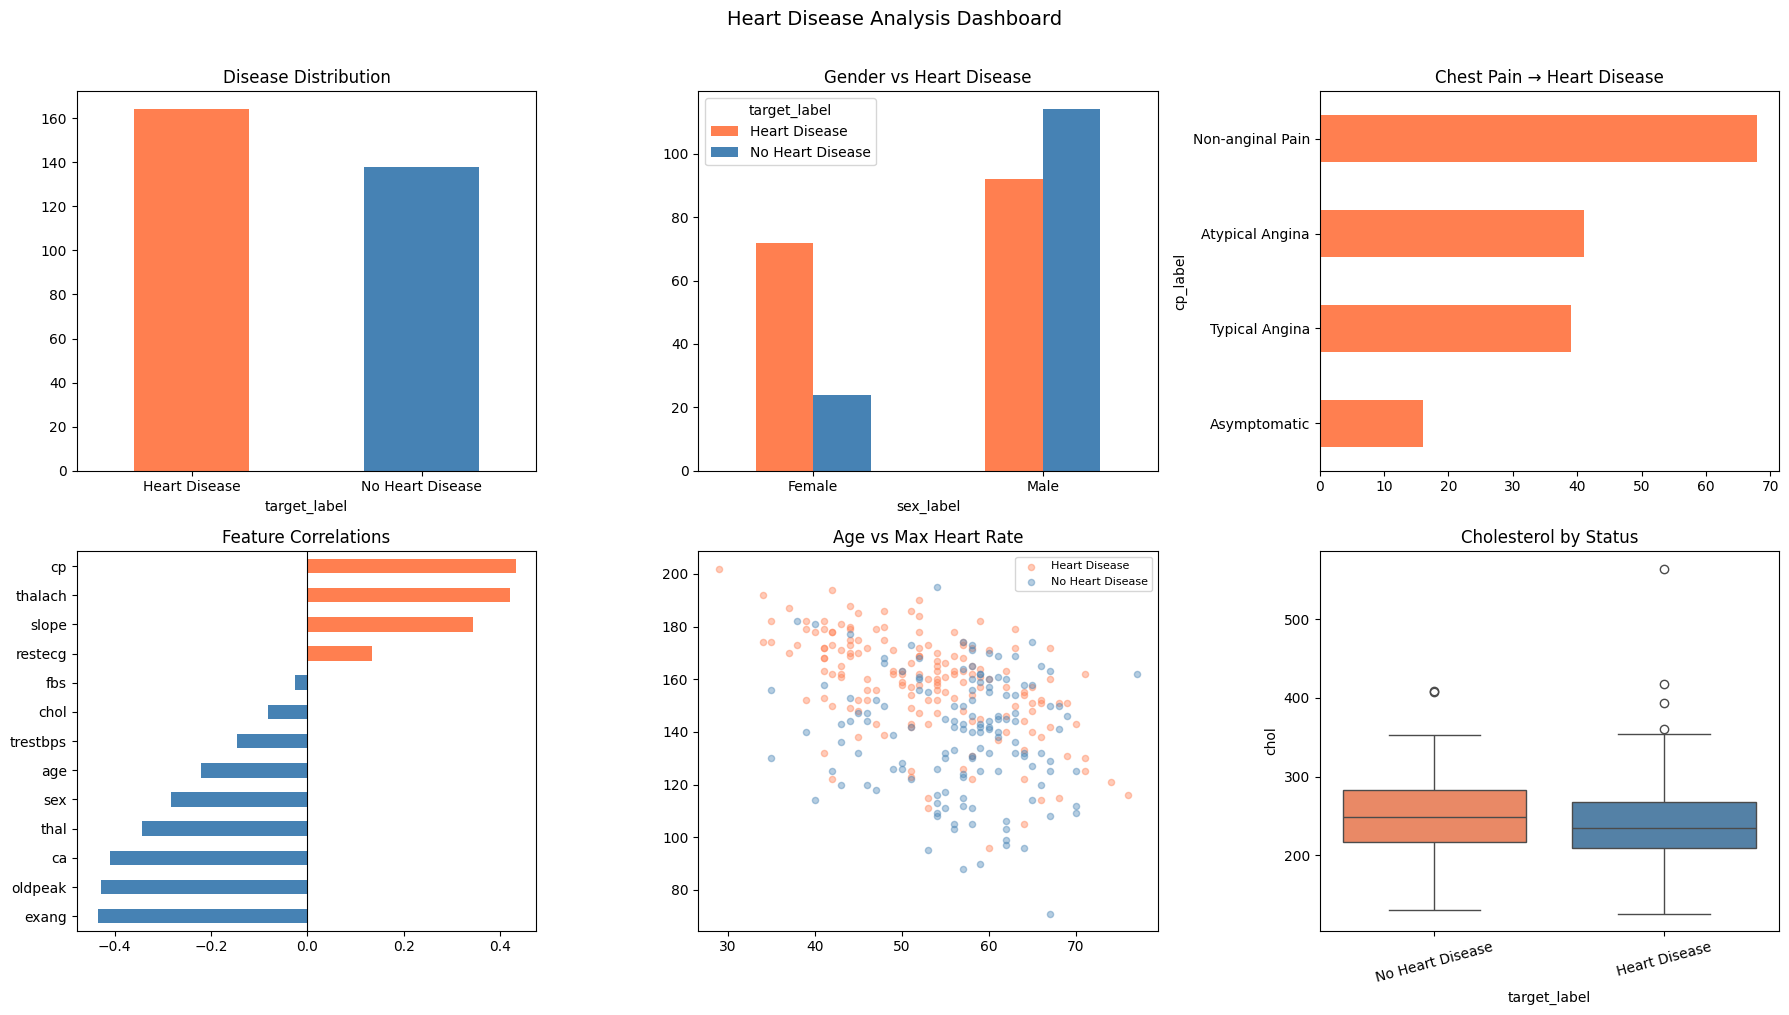

In [73]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Heart Disease Analysis Dashboard", fontsize=14, y=1.01)

# 1. Target distribution
data['target_label'].value_counts().plot(kind='bar', ax=axes[0,0],
    color=['coral','steelblue'])
axes[0,0].set_title("Disease Distribution")
axes[0,0].tick_params(axis='x', rotation=0)

# 2. Gender vs disease
pd.crosstab(data['sex_label'], data['target_label']).plot(
    kind='bar', ax=axes[0,1], color=['coral','steelblue'])
axes[0,1].set_title("Gender vs Heart Disease")
axes[0,1].tick_params(axis='x', rotation=0)

# 3. Chest pain type
pd.crosstab(data['cp_label'], data['target_label'])['Heart Disease'].sort_values().plot(
    kind='barh', ax=axes[0,2], color='coral')
axes[0,2].set_title("Chest Pain → Heart Disease")

# 4. Correlation with target
corr_with_target.plot(kind='barh', ax=axes[1,0],
    color=['coral' if x>0 else 'steelblue' for x in corr_with_target])
axes[1,0].axvline(0, color='black', linewidth=0.8)
axes[1,0].set_title("Feature Correlations")

# 5. Age vs thalach scatter
for label, color in zip(['Heart Disease','No Heart Disease'],['coral','steelblue']):
    s = data[data['target_label']==label]
    axes[1,1].scatter(s['age'], s['thalach'], color=color, alpha=0.4, s=20, label=label)
axes[1,1].set_title("Age vs Max Heart Rate")
axes[1,1].legend(fontsize=8)

# 6. Cholesterol boxplot
sns.boxplot(x='target_label', y='chol', data=data,
            palette=['coral','steelblue'], ax=axes[1,2])
axes[1,2].set_title("Cholesterol by Status")
axes[1,2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## 8. Key Insights

After analyzing **302 patient records** (after removing 723 duplicate rows):

1. **The dataset was 70% duplicates — a critical data quality issue**  
   1,025 rows reduced to 302 unique records after `drop_duplicates()`. Always check before analysis.

2. **Men have a higher heart disease rate than women in this dataset**  
   The cross-tabulation shows men account for ~55% of heart disease cases, though women show higher rates proportionally when adjusted for count.

3. **Asymptomatic chest pain (cp=3) is the most dangerous**  
   Counter-intuitively, patients with NO chest pain symptoms have the highest heart disease rate — making asymptomatic presentation a major risk factor.

4. **thalach (max heart rate) is the strongest negative predictor**  
   Lower maximum heart rate strongly correlates with heart disease — as the heart becomes less able to reach peak performance under stress.

5. **oldpeak (ST depression) and ca (vessel count) are the strongest positive predictors**  
   These two clinical measurements show the highest positive correlation with heart disease in the dataset.

6. **Exercise-induced angina (exang=1) is 3x more common in heart disease patients**  
   Among patients with exang=Yes, ~76% have heart disease vs ~25% in those without exercise angina.
